# Preparacion de los datos
Consideraciones importantes: 


* Seleccionar el Kernel kagle(3.12.10)
*  Instalacion de kagglehub

In [31]:
#Importaciones
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import PIL

from glob import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, Flatten, Dense, AvgPool2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet import ResNet50





In [32]:
# Descarga de la ultiama version del dataset de Kaggle
path = kagglehub.dataset_download("chrisfilo/fruit-recognition")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\josej\.cache\kagglehub\datasets\chrisfilo\fruit-recognition\versions\1


In [33]:
#Creacion de clases para generar el dataset
classes = sorted([d for d in os.listdir(path)
                  if os.path.isdir(os.path.join(path, d))])

In [34]:
#Creacion de la lista de rutas de imagenes
image_paths = []
for ext in ("jpg", "jpeg", "png", "JPG", "JPEG", "PNG"):
    image_paths.extend(glob(os.path.join(path, "*", f"*.{ext}")))

In [35]:
#Creacion de un DataFrame con las rutas de imagenes y sus etiquetas
df = pd.DataFrame({'image_path': image_paths})
df['label'] = df['image_path'].apply(lambda p: os.path.basename(os.path.dirname(p)))
print("Se ha creeado el dataframe con la informacion de las imagenes y sus etiquetas")

Se ha creeado el dataframe con la informacion de las imagenes y sus etiquetas


Forma del dataframe: (62402, 2)
<class 'pandas.DataFrame'>
RangeIndex: 62402 entries, 0 to 62401
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_path  62402 non-null  str  
 1   label       62402 non-null  str  
dtypes: str(2)
memory usage: 975.2 KB


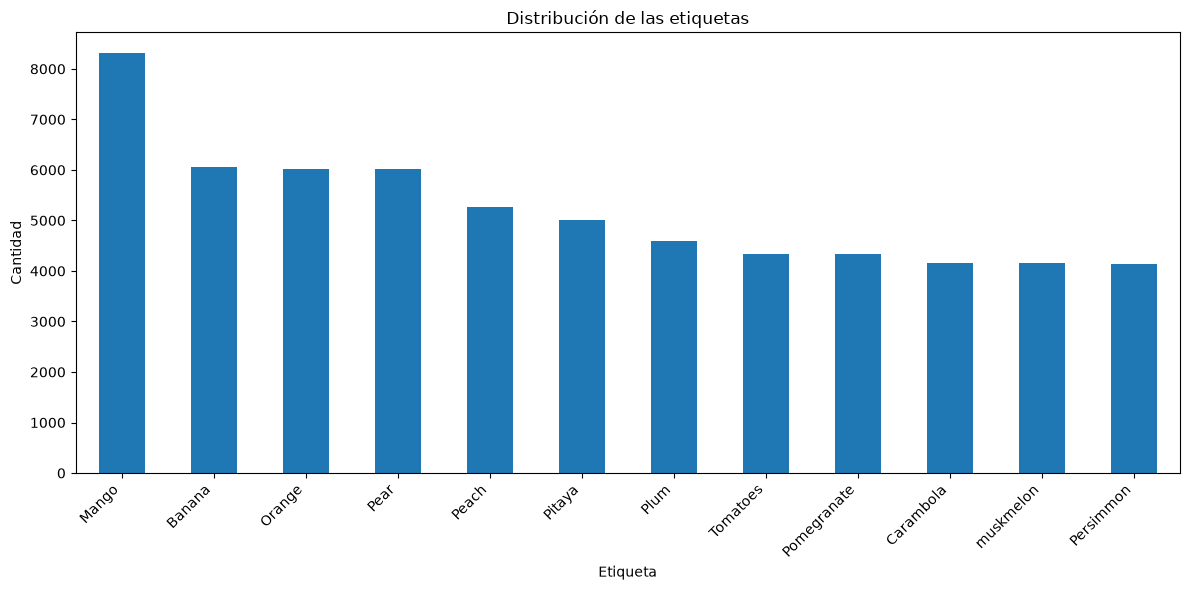

In [36]:
#Analisis exploratorio de los datos
print("Forma del dataframe:", df.shape)
df.info()

label_counts = df['label'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Distribución de las etiquetas')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Procesamiento de los datos

In [37]:
#Generamos los datos para las etiquetas 
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

#Particionamos el dataset en entrenamiento y prueba
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label_id"], random_state=12345,)


In [46]:
#Funcion para cargar las imagenes
img_size = (128, 128)
batch = 32

def load_data(df, direct=None):
    datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,
        vertical_flip=True,
        horizontal_flip=True
    )

    data_gen_flow = datagen.flow_from_dataframe(
        df,
        directory=direct,
        x_col='image_path',
        y_col='label',
        target_size=(150, 150),
        batch_size=16,
        class_mode='sparse',
        seed=12345
    )

    return data_gen_flow


def create_model(input_shape):
    model = Sequential()

    model.add(Conv2D(6, (5, 5), padding='same', activation='relu',
                     input_shape=input_shape))
                     
    # Añade una capa pooling aquí (MaxPool2D o AvgPool2D)
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(16, (5, 5), padding='valid', activation='relu'))
    
    # Añade una capa pooling aquí (MaxPool2D o AvgPool2D)
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(16, (5, 5), padding='valid', activation='relu'))
    
    # Añade una capa pooling aquí (MaxPool2D o AvgPool2D)
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Añade una capa flatten aquí
    model.add(Flatten())
    
    # Añade 3 capas dense aquí 
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(12, activation='softmax'))

    optimizer = Adam(learning_rate=0.0001)
    
    model.compile(optimizer=optimizer, 
                                loss= 'sparse_categorical_crossentropy',
                  metrics=['acc'])

    return model



def train_model(model, train_data, test_data, 
                batch_size=None, 
                epochs=10, 
                steps_per_epoch=None, 
                validation_steps=None):

   model.fit(train_data,
          validation_data=test_data,
          batch_size=batch_size,
          epochs=epochs,
          verbose=2)

   return model


In [51]:
input_shape = (150, 150, 3)
train_data = load_data(train_df)
test_data = load_data(test_df)
model = create_model(input_shape)
model = train_model(model, train_data, test_data, epochs=10)

Found 49921 validated image filenames belonging to 12 classes.
Found 12481 validated image filenames belonging to 12 classes.


c:\Users\josej\Documents\pythonCode\TripleTen\kagle\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3121/3121 - 557s - 178ms/step - acc: 0.6513 - loss: 0.9725 - val_acc: 0.8660 - val_loss: 0.4084
Epoch 2/10
3121/3121 - 344s - 110ms/step - acc: 0.8914 - loss: 0.3275 - val_acc: 0.9116 - val_loss: 0.2771
Epoch 3/10
3121/3121 - 368s - 118ms/step - acc: 0.9302 - loss: 0.2186 - val_acc: 0.9401 - val_loss: 0.1838
Epoch 4/10
3121/3121 - 16891s - 5s/step - acc: 0.9423 - loss: 0.1716 - val_acc: 0.9468 - val_loss: 0.1535
Epoch 5/10
3121/3121 - 320s - 102ms/step - acc: 0.9523 - loss: 0.1444 - val_acc: 0.9668 - val_loss: 0.0997
Epoch 6/10
3121/3121 - 302s - 97ms/step - acc: 0.9594 - loss: 0.1231 - val_acc: 0.9673 - val_loss: 0.1011
Epoch 7/10
3121/3121 - 312s - 100ms/step - acc: 0.9643 - loss: 0.1087 - val_acc: 0.9678 - val_loss: 0.0926
Epoch 8/10
3121/3121 - 295s - 95ms/step - acc: 0.9705 - loss: 0.0910 - val_acc: 0.9646 - val_loss: 0.1195
Epoch 9/10
3121/3121 - 294s - 94ms/step - acc: 0.9728 - loss: 0.0828 - val_acc: 0.9764 - val_loss: 0.0725
Epoch 10/10
3121/3121 - 294s - 94ms/step 